In [ ]:
#1. What is the main business problem?
SmartLoan Partners processes a high volume of small business loan applications each month. The business problem is how to make the 
process faster, more consistent, and more data-driven without removing human review from high-stakes decisions. Machine learning is used to build 
a decision-support tool that helps prioritize applications and flag risky cases early.

#2. Why is customer/user segmentation useful for this business?
Not all loan applicants carry the same level of financial risk. Some applicants have strong credit scores, better cash flow, and great revenue,
 which they are likely to repay. Others may have a history of defaults, low profitability, or high existing debt; they represent a higher risk. 
Segmenting applicants into groups based on their financial profiles allows SmartLoan to allocate underwriting resources efficiently, 
design targeted lending products, and apply the right level of scrutiny to each group rather than treating all applications the same way.

#3. What kind of marketing decisions could be improved by discovering customer/user groups?
Knowing applicant segments allows SmartLoan to make more targeted and effective lending decisions, including which applicants to fast-track
for approval, which to route to additional document review, what loan terms or interest rates to offer each group, and how to design financial 
services for low-risk or high-risk applicants. Marketing communications can also be tailored, for example, offering premium loan products
to low-risk borrowers while providing financial readiness resources to high-risk ones.

In [1]:
print("Unsupervised Learning for Pattern Discovery")
print("--------------------------------------------------")
print("In unsupervised learning, there is no target variable.")
print("The goal is to discover hidden patterns or groups in the data.")
print("Example business use case: Customer Segmentation")

Unsupervised Learning for Pattern Discovery
--------------------------------------------------
In unsupervised learning, there is no target variable.
The goal is to discover hidden patterns or groups in the data.
Example business use case: Customer Segmentation


In [3]:
import pandas as pd

from IPython.display import display

file_path = r"C:\Users\luqma\Downloads\smartloan_business_loan_decision_tree_dataset.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")

print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (244, 16)


,Application_ID,Industry,Region,Business_Age_Years,Annual_Revenue,Monthly_Profit,Existing_Debt,Credit_Score,Requested_Loan_Amount,Loan_Term_Months,Collateral_Value,Previous_Default,Online_Application_Complete,Relationship_Length_Months,Cash_Flow_Stability,Loan_Approved
0,SL-0001,Health Services,Alberta,9,430092.0,2058.0,11573.0,667.0,10000,48,2652.0,No,Yes,20.0,High,Yes
1,SL-0002,Education Services,Ontario,6,102057.0,-739.0,83367.0,563.0,25000,60,4761.0,No,Yes,39.0,Low,No
2,SL-0003,Professional Services,Manitoba,6,244945.0,1138.0,170897.0,749.0,10000,12,3585.0,No,Yes,25.0,High,Yes
3,SL-0004,E-commerce,Alberta,0,267415.0,5003.0,91078.0,622.0,20000,24,13003.0,No,Yes,20.0,High,Yes
4,SL-0005,E-commerce,Manitoba,9,139350.0,1333.0,40216.0,641.0,30000,36,14442.0,Yes,No,24.0,Medium,No


In [4]:
df.head()

,Application_ID,Industry,Region,Business_Age_Years,Annual_Revenue,Monthly_Profit,Existing_Debt,Credit_Score,Requested_Loan_Amount,Loan_Term_Months,Collateral_Value,Previous_Default,Online_Application_Complete,Relationship_Length_Months,Cash_Flow_Stability,Loan_Approved
0,SL-0001,Health Services,Alberta,9,430092.0,2058.0,11573.0,667.0,10000,48,2652.0,No,Yes,20.0,High,Yes
1,SL-0002,Education Services,Ontario,6,102057.0,-739.0,83367.0,563.0,25000,60,4761.0,No,Yes,39.0,Low,No
2,SL-0003,Professional Services,Manitoba,6,244945.0,1138.0,170897.0,749.0,10000,12,3585.0,No,Yes,25.0,High,Yes
3,SL-0004,E-commerce,Alberta,0,267415.0,5003.0,91078.0,622.0,20000,24,13003.0,No,Yes,20.0,High,Yes
4,SL-0005,E-commerce,Manitoba,9,139350.0,1333.0,40216.0,641.0,30000,36,14442.0,Yes,No,24.0,Medium,No


In [5]:
df.shape

(244, 16)

In [6]:
df.columns

Index(['Application_ID', 'Industry', 'Region', 'Business_Age_Years',
       'Annual_Revenue', 'Monthly_Profit', 'Existing_Debt', 'Credit_Score',
       'Requested_Loan_Amount', 'Loan_Term_Months', 'Collateral_Value',
       'Previous_Default', 'Online_Application_Complete',
       'Relationship_Length_Months', 'Cash_Flow_Stability', 'Loan_Approved'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Application_ID               244 non-null    object 
 1   Industry                     243 non-null    object 
 2   Region                       243 non-null    object 
 3   Business_Age_Years           244 non-null    int64  
 4   Annual_Revenue               243 non-null    float64
 5   Monthly_Profit               243 non-null    float64
 6   Existing_Debt                243 non-null    float64
 7   Credit_Score                 243 non-null    float64
 8   Requested_Loan_Amount        244 non-null    int64  
 9   Loan_Term_Months             244 non-null    int64  
 10  Collateral_Value             243 non-null    float64
 11  Previous_Default             243 non-null    object 
 12  Online_Application_Complete  244 non-null    object 
 13  Relationship_Length_

In [8]:
df.isnull().sum()

Application_ID                 0
Industry                       1
Region                         1
Business_Age_Years             0
Annual_Revenue                 1
Monthly_Profit                 1
Existing_Debt                  1
Credit_Score                   1
Requested_Loan_Amount          0
Loan_Term_Months               0
Collateral_Value               1
Previous_Default               1
Online_Application_Complete    0
Relationship_Length_Months     1
Cash_Flow_Stability            1
Loan_Approved                  0
dtype: int64

In [9]:
df.describe()

,Business_Age_Years,Annual_Revenue,Monthly_Profit,Existing_Debt,Credit_Score,Requested_Loan_Amount,Loan_Term_Months,Collateral_Value,Relationship_Length_Months
count,244.000000,2.430000e+02,243.000000,243.000000,243.000000,244.000000,244.000000,243.000000,243.000000
mean,5.155738,2.449682e+05,2245.090535,50427.654321,665.897119,65512.295082,35.704918,50679.518519,38.658436
std,3.177909,1.855704e+05,2267.954878,41081.429108,64.541115,62931.178136,17.652656,61285.028942,20.893339
min,0.000000,4.500000e+04,-2005.000000,5542.000000,499.000000,10000.000000,12.000000,0.000000,0.000000
25%,3.000000,1.178830e+05,802.000000,22473.500000,616.500000,20000.000000,24.000000,13046.500000,24.000000
50%,5.000000,1.911800e+05,1934.000000,39308.000000,670.000000,40000.000000,36.000000,25430.000000,39.000000
75%,7.000000,3.030265e+05,3104.000000,65984.500000,715.500000,100000.000000,48.000000,63922.500000,52.000000
max,15.000000,1.279539e+06,17753.000000,261063.000000,837.000000,200000.000000,60.000000,321168.000000,95.000000


In [13]:
print("Dataset columns:")
print(df.columns)

print("\nIn this dataset, we have a target variable which is Laon_Approval.")
print("We are predicting a label such as Yes/No or 0/1.")

Dataset columns:
Index(['Application_ID', 'Industry', 'Region', 'Business_Age_Years',
       'Annual_Revenue', 'Monthly_Profit', 'Existing_Debt', 'Credit_Score',
       'Requested_Loan_Amount', 'Loan_Term_Months', 'Collateral_Value',
       'Previous_Default', 'Online_Application_Complete',
       'Relationship_Length_Months', 'Cash_Flow_Stability', 'Loan_Approved'],
      dtype='object')

In this dataset, we have a target variable which is Laon_Approval.
We are predicting a label such as Yes/No or 0/1.


In [11]:

print("Supervised learning: X = features, y = target")
print("Unsupervised learning: X = features only, no y")

Supervised learning: X = features, y = target
Unsupervised learning: X = features only, no y


In [12]:
df.columns

Index(['Application_ID', 'Industry', 'Region', 'Business_Age_Years',
       'Annual_Revenue', 'Monthly_Profit', 'Existing_Debt', 'Credit_Score',
       'Requested_Loan_Amount', 'Loan_Term_Months', 'Collateral_Value',
       'Previous_Default', 'Online_Application_Complete',
       'Relationship_Length_Months', 'Cash_Flow_Stability', 'Loan_Approved'],
      dtype='object')

In [16]:
features = [
    'Industry',
    'Region',
    'Business_Age_Years',
    'Annual_Revenue',
    'Monthly_Profit',
    'Existing_Debt',
    'Credit_Score',
    'Requested_Loan_Amount',
    'Loan_Term_Months',
    'Collateral_Value',
    'Previous_Default',
    'Online_Application_Complete',
    'Relationship_Length_Months',
    'Cash_Flow_Stability'
]

# Create feature matrix
X = df[features]

# Display the selected features
X.head()


,Industry,Region,Business_Age_Years,Annual_Revenue,Monthly_Profit,Existing_Debt,Credit_Score,Requested_Loan_Amount,Loan_Term_Months,Collateral_Value,Previous_Default,Online_Application_Complete,Relationship_Length_Months,Cash_Flow_Stability
0,Health Services,Alberta,9,430092.0,2058.0,11573.0,667.0,10000,48,2652.0,No,Yes,20.0,High
1,Education Services,Ontario,6,102057.0,-739.0,83367.0,563.0,25000,60,4761.0,No,Yes,39.0,Low
2,Professional Services,Manitoba,6,244945.0,1138.0,170897.0,749.0,10000,12,3585.0,No,Yes,25.0,High
3,E-commerce,Alberta,0,267415.0,5003.0,91078.0,622.0,20000,24,13003.0,No,Yes,20.0,High
4,E-commerce,Manitoba,9,139350.0,1333.0,40216.0,641.0,30000,36,14442.0,Yes,No,24.0,Medium


In [17]:
y = df['Loan_Approved']

# Display first few target values
y.head()

0    Yes
1     No
2    Yes
3    Yes
4     No
Name: Loan_Approved, dtype: object

In [18]:
print("Original dataset shape:", df.shape)
print("Selected features shape:", X.shape)

Original dataset shape: (244, 16)
Selected features shape: (244, 14)


In [19]:
print("Features selected for clustering:")
for feature in features:
    print("-", feature)

Features selected for clustering:
- Industry
- Region
- Business_Age_Years
- Annual_Revenue
- Monthly_Profit
- Existing_Debt
- Credit_Score
- Requested_Loan_Amount
- Loan_Term_Months
- Collateral_Value
- Previous_Default
- Online_Application_Complete
- Relationship_Length_Months
- Cash_Flow_Stability


In [20]:
df_clean = df.copy()

# Display original shape
print("Original dataset shape:", df_clean.shape)

Original dataset shape: (244, 16)


In [21]:
df_clean.columns = df_clean.columns.str.strip()

# Display cleaned column names
df_clean.columns

Index(['Application_ID', 'Industry', 'Region', 'Business_Age_Years',
       'Annual_Revenue', 'Monthly_Profit', 'Existing_Debt', 'Credit_Score',
       'Requested_Loan_Amount', 'Loan_Term_Months', 'Collateral_Value',
       'Previous_Default', 'Online_Application_Complete',
       'Relationship_Length_Months', 'Cash_Flow_Stability', 'Loan_Approved'],
      dtype='object')

In [22]:
duplicate_count = df_clean.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 4


In [23]:
df_clean = df_clean.drop_duplicates()

print("Dataset shape after removing duplicates:", df_clean.shape)

Dataset shape after removing duplicates: (240, 16)


In [24]:
df_clean.isnull().sum()

Application_ID                 0
Industry                       1
Region                         1
Business_Age_Years             0
Annual_Revenue                 1
Monthly_Profit                 1
Existing_Debt                  1
Credit_Score                   1
Requested_Loan_Amount          0
Loan_Term_Months               0
Collateral_Value               1
Previous_Default               1
Online_Application_Complete    0
Relationship_Length_Months     1
Cash_Flow_Stability            1
Loan_Approved                  0
dtype: int64

In [25]:
df_clean.head()

,Application_ID,Industry,Region,Business_Age_Years,Annual_Revenue,Monthly_Profit,Existing_Debt,Credit_Score,Requested_Loan_Amount,Loan_Term_Months,Collateral_Value,Previous_Default,Online_Application_Complete,Relationship_Length_Months,Cash_Flow_Stability,Loan_Approved
0,SL-0001,Health Services,Alberta,9,430092.0,2058.0,11573.0,667.0,10000,48,2652.0,No,Yes,20.0,High,Yes
1,SL-0002,Education Services,Ontario,6,102057.0,-739.0,83367.0,563.0,25000,60,4761.0,No,Yes,39.0,Low,No
2,SL-0003,Professional Services,Manitoba,6,244945.0,1138.0,170897.0,749.0,10000,12,3585.0,No,Yes,25.0,High,Yes
3,SL-0004,E-commerce,Alberta,0,267415.0,5003.0,91078.0,622.0,20000,24,13003.0,No,Yes,20.0,High,Yes
4,SL-0005,E-commerce,Manitoba,9,139350.0,1333.0,40216.0,641.0,30000,36,14442.0,Yes,No,24.0,Medium,No


In [26]:
df_clean.isnull().sum()

Application_ID                 0
Industry                       1
Region                         1
Business_Age_Years             0
Annual_Revenue                 1
Monthly_Profit                 1
Existing_Debt                  1
Credit_Score                   1
Requested_Loan_Amount          0
Loan_Term_Months               0
Collateral_Value               1
Previous_Default               1
Online_Application_Complete    0
Relationship_Length_Months     1
Cash_Flow_Stability            1
Loan_Approved                  0
dtype: int64

In [27]:
numerical_columns = [
    'Business_Age_Years',
    'Annual_Revenue',
    'Monthly_Profit',
    'Existing_Debt',
    'Credit_Score',
    'Requested_Loan_Amount',
    'Loan_Term_Months',
    'Collateral_Value',
    'Relationship_Length_Months'
]

# Fill missing values in numerical columns with the median
for col in numerical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Check missing values again
df_clean[numerical_columns].isnull().sum()

Business_Age_Years            0
Annual_Revenue                0
Monthly_Profit                0
Existing_Debt                 0
Credit_Score                  0
Requested_Loan_Amount         0
Loan_Term_Months              0
Collateral_Value              0
Relationship_Length_Months    0
dtype: int64

In [28]:
X = df_clean[numerical_columns]

# Display the selected features
X.head()

,Business_Age_Years,Annual_Revenue,Monthly_Profit,Existing_Debt,Credit_Score,Requested_Loan_Amount,Loan_Term_Months,Collateral_Value,Relationship_Length_Months
0,9,430092.0,2058.0,11573.0,667.0,10000,48,2652.0,20.0
1,6,102057.0,-739.0,83367.0,563.0,25000,60,4761.0,39.0
2,6,244945.0,1138.0,170897.0,749.0,10000,12,3585.0,25.0
3,0,267415.0,5003.0,91078.0,622.0,20000,24,13003.0,20.0
4,9,139350.0,1333.0,40216.0,641.0,30000,36,14442.0,24.0


In [29]:
# Confirm that there are no missing values in X

X.isnull().sum()

Business_Age_Years            0
Annual_Revenue                0
Monthly_Profit                0
Existing_Debt                 0
Credit_Score                  0
Requested_Loan_Amount         0
Loan_Term_Months              0
Collateral_Value              0
Relationship_Length_Months    0
dtype: int64

In [30]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Scale the selected features
X_scaled = scaler.fit_transform(X)

# Display the scaled data
X_scaled

array([[ 1.21425084,  0.99169951, -0.09190367, ...,  0.69999203,
        -0.78672763, -0.89774615],
       [ 0.27114339, -0.77389252, -1.32801532, ...,  1.38014622,
        -0.75213746,  0.01399604],
       [ 0.27114339, -0.00482241, -0.49849027, ..., -1.34047056,
        -0.77142529, -0.657814  ],
       ...,
       [ 1.84298914, -0.26522483,  0.16088713, ...,  1.38014622,
        -0.61338316,  1.50157541],
       [-0.35759491,  0.18864538,  1.01516093, ..., -0.66031636,
        -0.36336301, -0.27392255],
       [-0.98633321, -0.48408644, -1.26437568, ...,  0.69999203,
        -0.00509483, -0.46586827]], shape=(240, 9))

In [31]:
X_scaled_df = pd.DataFrame(X_scaled, columns=numerical_columns)

X_scaled_df.head()

,Business_Age_Years,Annual_Revenue,Monthly_Profit,Existing_Debt,Credit_Score,Requested_Loan_Amount,Loan_Term_Months,Collateral_Value,Relationship_Length_Months
0,1.214251,0.991700,-0.091904,-0.942713,0.010919,-0.890361,0.699992,-0.786728,-0.897746
1,0.271143,-0.773893,-1.328015,0.798193,-1.601686,-0.650174,1.380146,-0.752137,0.013996
2,0.271143,-0.004822,-0.498490,2.920675,1.282396,-0.890361,-1.340471,-0.771425,-0.657814
3,-1.615072,0.116119,1.209615,0.985174,-0.686843,-0.730237,-0.660316,-0.616959,-0.897746
4,1.214251,-0.573169,-0.412312,-0.248159,-0.392233,-0.570112,0.019838,-0.593357,-0.705800


In [32]:
# Check the mean and standard deviation after scaling

print("Mean after scaling:")
print(X_scaled_df.mean())

print("\nStandard deviation after scaling:")
print(X_scaled_df.std())

Mean after scaling:
Business_Age_Years           -4.440892e-17
Annual_Revenue                4.070818e-17
Monthly_Profit               -8.511710e-17
Existing_Debt                 5.921189e-17
Credit_Score                 -2.072416e-16
Requested_Loan_Amount        -9.344377e-17
Loan_Term_Months              7.401487e-17
Collateral_Value              4.070818e-17
Relationship_Length_Months   -9.251859e-17
dtype: float64

Standard deviation after scaling:
Business_Age_Years            1.00209
Annual_Revenue                1.00209
Monthly_Profit                1.00209
Existing_Debt                 1.00209
Credit_Score                  1.00209
Requested_Loan_Amount         1.00209
Loan_Term_Months              1.00209
Collateral_Value              1.00209
Relationship_Length_Months    1.00209
dtype: float64


In [33]:
import pandas as pd

kmeans_intro = pd.DataFrame({
    "Concept": [
        "K-means",
        "K",
        "Cluster",
        "Centroid",
        "Business Use"
    ],
    "Meaning": [
        "An unsupervised learning algorithm used to group similar data points",
        "The number of clusters selected by the user",
        "A group of similar customers or users",
        "The center point of a cluster",
        "Customer segmentation and pattern discovery"
    ]
})

kmeans_intro

,Concept,Meaning
0,K-means,An unsupervised learning algorithm used to gro...
1,K,The number of clusters selected by the user
2,Cluster,A group of similar customers or users
3,Centroid,The center point of a cluster
4,Business Use,Customer segmentation and pattern discovery


In [34]:
import pandas as pd

k_options = pd.DataFrame({
    "K Value": [2, 3, 4, 5, 6],
    "Meaning": [
        "Customers are divided into 2 broad groups",
        "Customers are divided into 3 main groups",
        "Customers are divided into 4 more detailed groups",
        "Customers are divided into 5 smaller groups",
        "Customers are divided into 6 very specific groups"
    ]
})

k_options

,K Value,Meaning
0,2,Customers are divided into 2 broad groups
1,3,Customers are divided into 3 main groups
2,4,Customers are divided into 4 more detailed groups
3,5,Customers are divided into 5 smaller groups
4,6,Customers are divided into 6 very specific groups


In [35]:
print("We need to choose a suitable number of clusters.")
print("The number of clusters is called K.")
print("Next, we will use the Elbow Method to compare different K values.")

We need to choose a suitable number of clusters.
The number of clusters is called K.
Next, we will use the Elbow Method to compare different K values.


C:\Users\luqma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\luqma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\luqma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\luqma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

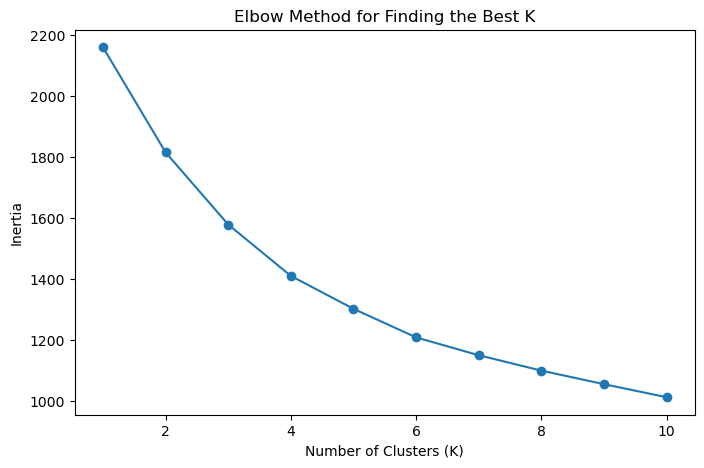

In [37]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Create an empty list to store inertia values
inertia = []

# Test different values of K
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Finding the Best K")
plt.show()

In [38]:
elbow_results = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertia
})

elbow_results

,K,Inertia
0,1,2160.000000
1,2,1814.999407
2,3,1578.197285
3,4,1409.648473
4,5,1301.666618
5,6,1207.921743
6,7,1149.337504
7,8,1098.893842
8,9,1054.413802
9,10,1011.596811


In [39]:
from sklearn.cluster import KMeans

# Create the K-means model with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Train the model and assign cluster labels
cluster_labels = kmeans.fit_predict(X_scaled)

# Display the first 10 cluster labels
cluster_labels[:10]

C:\Users\luqma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([1, 1, 1, 0, 1, 1, 1, 2, 1, 1], dtype=int32)

In [40]:
import pandas as pd

pd.Series(cluster_labels).value_counts().sort_index()

0     34
1    156
2     50
Name: count, dtype: int64

In [41]:
# Step 15: Add Cluster Labels to the Dataset

# Create a copy of the cleaned dataset
df_clustered = df_clean.copy()

# Add cluster labels to the dataset
df_clustered["Cluster"] = cluster_labels

# Display the first five rows
df_clustered.head()

,Application_ID,Industry,Region,Business_Age_Years,Annual_Revenue,Monthly_Profit,Existing_Debt,Credit_Score,Requested_Loan_Amount,Loan_Term_Months,Collateral_Value,Previous_Default,Online_Application_Complete,Relationship_Length_Months,Cash_Flow_Stability,Loan_Approved,Cluster
0,SL-0001,Health Services,Alberta,9,430092.0,2058.0,11573.0,667.0,10000,48,2652.0,No,Yes,20.0,High,Yes,1
1,SL-0002,Education Services,Ontario,6,102057.0,-739.0,83367.0,563.0,25000,60,4761.0,No,Yes,39.0,Low,No,1
2,SL-0003,Professional Services,Manitoba,6,244945.0,1138.0,170897.0,749.0,10000,12,3585.0,No,Yes,25.0,High,Yes,1
3,SL-0004,E-commerce,Alberta,0,267415.0,5003.0,91078.0,622.0,20000,24,13003.0,No,Yes,20.0,High,Yes,0
4,SL-0005,E-commerce,Manitoba,9,139350.0,1333.0,40216.0,641.0,30000,36,14442.0,Yes,No,24.0,Medium,No,1


In [42]:

df_clustered["Cluster"].value_counts().sort_index()

Cluster
0     34
1    156
2     50
Name: count, dtype: int64

In [43]:
df_clustered[
    [
        "Application_ID",
        "Industry",
        "Region",
        "Business_Age_Years",
        "Annual_Revenue",
        "Monthly_Profit",
        "Credit_Score",
        "Requested_Loan_Amount",
        "Loan_Approved",
        "Cluster"
    ]
].head(10)

,Application_ID,Industry,Region,Business_Age_Years,Annual_Revenue,Monthly_Profit,Credit_Score,Requested_Loan_Amount,Loan_Approved,Cluster
0,SL-0001,Health Services,Alberta,9,430092.0,2058.0,667.0,10000,Yes,1
1,SL-0002,Education Services,Ontario,6,102057.0,-739.0,563.0,25000,No,1
2,SL-0003,Professional Services,Manitoba,6,244945.0,1138.0,749.0,10000,Yes,1
3,SL-0004,E-commerce,Alberta,0,267415.0,5003.0,622.0,20000,Yes,0
4,SL-0005,E-commerce,Manitoba,9,139350.0,1333.0,641.0,30000,No,1
5,SL-0006,Construction,Ontario,4,63277.0,-1205.0,638.0,20000,No,1
6,SL-0007,Manufacturing,Alberta,6,232993.0,3139.0,730.0,75000,Yes,1
7,SL-0008,Health Services,Quebec,3,433530.0,2961.0,608.0,150000,No,2
8,SL-0009,Construction,Quebec,5,241164.0,2110.0,545.0,30000,Yes,1
9,SL-0010,Restaurant,Alberta,5,208647.0,2482.0,749.0,50000,Yes,1


In [44]:
cluster_summary = df_clustered.groupby("Cluster")[numerical_columns].mean()

# Display the cluster summary
cluster_summary

,Business_Age_Years,Annual_Revenue,Monthly_Profit,Existing_Debt,Credit_Score,Requested_Loan_Amount,Loan_Term_Months,Collateral_Value,Relationship_Length_Months
Cluster,,,,,,,,,
0,3.588235,566444.647059,6144.323529,58417.558824,647.235294,66764.705882,33.882353,42379.117647,26.470588
1,5.641026,196717.782051,1676.967949,49139.634615,667.903846,32852.564103,35.615385,23675.282051,40.910256
2,4.620000,181094.820000,1466.300000,49120.160000,674.240000,167000.000000,36.960000,140289.580000,40.160000


In [45]:
# Round the values for easier interpretation

cluster_summary_rounded = cluster_summary.round(2)

cluster_summary_rounded

,Business_Age_Years,Annual_Revenue,Monthly_Profit,Existing_Debt,Credit_Score,Requested_Loan_Amount,Loan_Term_Months,Collateral_Value,Relationship_Length_Months
Cluster,,,,,,,,,
0,3.59,566444.65,6144.32,58417.56,647.24,66764.71,33.88,42379.12,26.47
1,5.64,196717.78,1676.97,49139.63,667.90,32852.56,35.62,23675.28,40.91
2,4.62,181094.82,1466.30,49120.16,674.24,167000.00,36.96,140289.58,40.16


In [46]:
# Count the number of customers in each cluster

cluster_counts = df_clustered["Cluster"].value_counts().sort_index()

cluster_counts

Cluster
0     34
1    156
2     50
Name: count, dtype: int64

In [47]:
cluster_summary_final = cluster_summary_rounded.copy()
cluster_summary_final["Number_of_Customers"] = cluster_counts

cluster_summary_final

,Business_Age_Years,Annual_Revenue,Monthly_Profit,Existing_Debt,Credit_Score,Requested_Loan_Amount,Loan_Term_Months,Collateral_Value,Relationship_Length_Months,Number_of_Customers
Cluster,,,,,,,,,,
0,3.59,566444.65,6144.32,58417.56,647.24,66764.71,33.88,42379.12,26.47,34
1,5.64,196717.78,1676.97,49139.63,667.90,32852.56,35.62,23675.28,40.91,156
2,4.62,181094.82,1466.30,49120.16,674.24,167000.00,36.96,140289.58,40.16,50


In [48]:
cluster_summary_final

,Business_Age_Years,Annual_Revenue,Monthly_Profit,Existing_Debt,Credit_Score,Requested_Loan_Amount,Loan_Term_Months,Collateral_Value,Relationship_Length_Months,Number_of_Customers
Cluster,,,,,,,,,,
0,3.59,566444.65,6144.32,58417.56,647.24,66764.71,33.88,42379.12,26.47,34
1,5.64,196717.78,1676.97,49139.63,667.90,32852.56,35.62,23675.28,40.91,156
2,4.62,181094.82,1466.30,49120.16,674.24,167000.00,36.96,140289.58,40.16,50


In [50]:
summary = cluster_summary_final.copy()

# Cluster with the highest average credit score
low_risk_cluster = summary["Credit_Score"].idxmax()

# Cluster with the highest annual revenue among remaining clusters
remaining_clusters = summary.drop(index=low_risk_cluster)
established_cluster = remaining_clusters["Annual_Revenue"].idxmax()

# Remaining cluster
higher_risk_cluster = summary.drop(
    index=[low_risk_cluster, established_cluster]
).index[0]

# Create business segment names
segment_names = {
    low_risk_cluster: "Low-Risk Businesses",
    established_cluster: "Established Businesses",
    higher_risk_cluster: "Higher-Risk Businesses"
}

# Add segment names to the clustered dataset
df_clustered["Segment_Name"] = df_clustered["Cluster"].map(segment_names)

# Display first rows
df_clustered.head()

,Application_ID,Industry,Region,Business_Age_Years,Annual_Revenue,Monthly_Profit,Existing_Debt,Credit_Score,Requested_Loan_Amount,Loan_Term_Months,Collateral_Value,Previous_Default,Online_Application_Complete,Relationship_Length_Months,Cash_Flow_Stability,Loan_Approved,Cluster,Segment_Name
0,SL-0001,Health Services,Alberta,9,430092.0,2058.0,11573.0,667.0,10000,48,2652.0,No,Yes,20.0,High,Yes,1,Higher-Risk Businesses
1,SL-0002,Education Services,Ontario,6,102057.0,-739.0,83367.0,563.0,25000,60,4761.0,No,Yes,39.0,Low,No,1,Higher-Risk Businesses
2,SL-0003,Professional Services,Manitoba,6,244945.0,1138.0,170897.0,749.0,10000,12,3585.0,No,Yes,25.0,High,Yes,1,Higher-Risk Businesses
3,SL-0004,E-commerce,Alberta,0,267415.0,5003.0,91078.0,622.0,20000,24,13003.0,No,Yes,20.0,High,Yes,0,Established Businesses
4,SL-0005,E-commerce,Manitoba,9,139350.0,1333.0,40216.0,641.0,30000,36,14442.0,Yes,No,24.0,Medium,No,1,Higher-Risk Businesses


In [51]:
# Create an interpretation table for SmartLoan loan applicant segments

segment_interpretation = pd.DataFrame({
    "Cluster": list(segment_names.keys()),
    "Segment Name": list(segment_names.values()),
    "Business Interpretation": [
        "High-creditworthiness applicants with strong annual revenue, positive monthly profit, high cash flow stability, and no prior defaults. Most likely to be approved.",
        "Moderate-risk applicants with average credit scores and medium cash flow stability. May have existing debt but demonstrate reasonable repayment capacity.",
        "High-risk applicants with low credit scores, negative monthly profit, low cash flow stability, or a history of previous defaults. Least likely to receive loan approval."
    ],
    "Possible Business Strategy": [
        "Fast-track loan approval, offer competitive interest rates, and consider higher loan limits or flexible terms to retain strong borrowers.",
        "Conduct additional financial review, request collateral documentation, and offer conditional approvals with structured repayment schedules.",
        "Flag for manual underwriting review, require stronger collateral, or offer financial advisory services before reapplication."
    ]
})

segment_interpretation

,Cluster,Segment Name,Business Interpretation,Possible Business Strategy
0,2,Low-Risk Businesses,High-creditworthiness applicants with strong a...,"Fast-track loan approval, offer competitive in..."
1,0,Established Businesses,Moderate-risk applicants with average credit s...,"Conduct additional financial review, request c..."
2,1,Higher-Risk Businesses,"High-risk applicants with low credit scores, n...","Flag for manual underwriting review, require s..."


In [52]:
df_clustered["Segment_Name"].value_counts()

Segment_Name
Higher-Risk Businesses    156
Low-Risk Businesses        50
Established Businesses     34
Name: count, dtype: int64

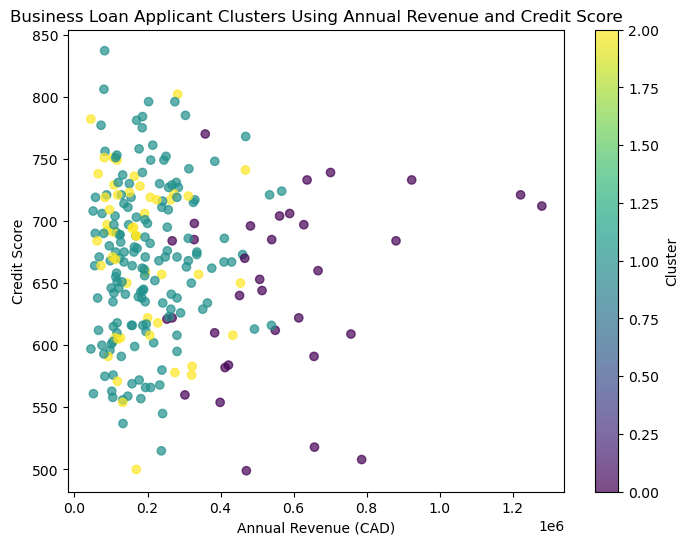

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    df_clustered["Annual_Revenue"],
    df_clustered["Credit_Score"],
    c=df_clustered["Cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Annual Revenue (CAD)")
plt.ylabel("Credit Score")
plt.title("Business Loan Applicant Clusters Using Annual Revenue and Credit Score")
plt.colorbar(scatter, label="Cluster")
plt.show()

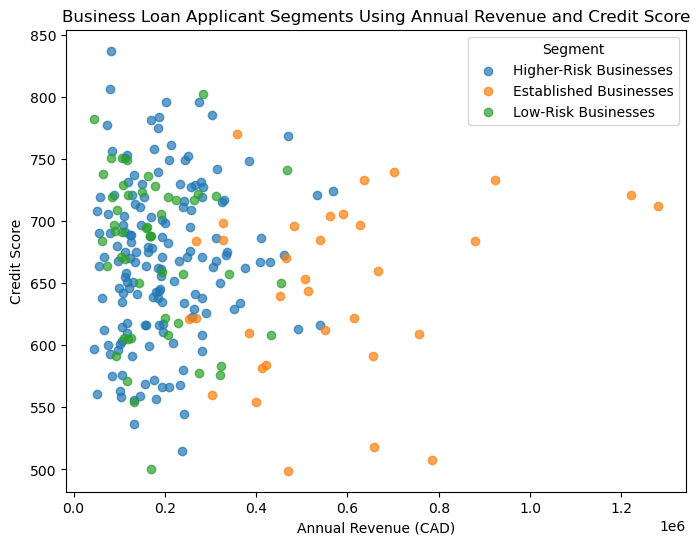

In [55]:
# Visualize clusters using segment names

plt.figure(figsize=(8, 6))

for segment in df_clustered["Segment_Name"].unique():
    segment_data = df_clustered[df_clustered["Segment_Name"] == segment]
    
    plt.scatter(
        segment_data["Annual_Revenue"],
        segment_data["Credit_Score"],
        label=segment,
        alpha=0.7
    )

plt.xlabel("Annual Revenue (CAD)")
plt.ylabel("Credit Score")
plt.title("Business Loan Applicant Segments Using Annual Revenue and Credit Score")
plt.legend(title="Segment")
plt.show()

In [56]:
import pandas as pd

pca_intro = pd.DataFrame({
    "Concept": [
        "PCA",
        "Full Name",
        "Main Purpose",
        "Why We Use It",
        "Important Note"
    ],
    "Meaning": [
        "A dimensionality reduction technique",
        "Principal Component Analysis",
        "To reduce many features into fewer components",
        "To visualize business loan applicant clusters in 2D",
        "PCA does not create clusters; it helps visualize them"
    ]
})

pca_intro

,Concept,Meaning
0,PCA,A dimensionality reduction technique
1,Full Name,Principal Component Analysis
2,Main Purpose,To reduce many features into fewer components
3,Why We Use It,To visualize business loan applicant clusters ...
4,Important Note,PCA does not create clusters; it helps visuali...


In [57]:
print("PCA stands for Principal Component Analysis.")
print("PCA helps reduce many features into fewer components.")
print("In this notebook, we use PCA to visualize business loan applicant clusters in 2D.")
print("PCA does not create clusters; K-Means creates the clusters.")

PCA stands for Principal Component Analysis.
PCA helps reduce many features into fewer components.
In this notebook, we use PCA to visualize business loan applicant clusters in 2D.
PCA does not create clusters; K-Means creates the clusters.


In [58]:
# Step 20: Apply PCA for Dimensionality Reduction

from sklearn.decomposition import PCA

# Create PCA model with 2 components
pca = PCA(n_components=2)

# Apply PCA to the scaled data
X_pca = pca.fit_transform(X_scaled)

# Add PCA components to the clustered dataset
df_clustered["PCA1"] = X_pca[:, 0]
df_clustered["PCA2"] = X_pca[:, 1]

# Display the first rows with PCA components
df_clustered.head()

,Application_ID,Industry,Region,Business_Age_Years,Annual_Revenue,Monthly_Profit,Existing_Debt,Credit_Score,Requested_Loan_Amount,Loan_Term_Months,Collateral_Value,Previous_Default,Online_Application_Complete,Relationship_Length_Months,Cash_Flow_Stability,Loan_Approved,Cluster,Segment_Name,PCA1,PCA2
0,SL-0001,Health Services,Alberta,9,430092.0,2058.0,11573.0,667.0,10000,48,2652.0,No,Yes,20.0,High,Yes,1,Higher-Risk Businesses,-0.608351,1.198917
1,SL-0002,Education Services,Ontario,6,102057.0,-739.0,83367.0,563.0,25000,60,4761.0,No,Yes,39.0,Low,No,1,Higher-Risk Businesses,-1.658158,-0.448186
2,SL-0003,Professional Services,Manitoba,6,244945.0,1138.0,170897.0,749.0,10000,12,3585.0,No,Yes,25.0,High,Yes,1,Higher-Risk Businesses,-0.832475,0.681289
3,SL-0004,E-commerce,Alberta,0,267415.0,5003.0,91078.0,622.0,20000,24,13003.0,No,Yes,20.0,High,Yes,0,Established Businesses,0.520406,1.633569
4,SL-0005,E-commerce,Manitoba,9,139350.0,1333.0,40216.0,641.0,30000,36,14442.0,Yes,No,24.0,Medium,No,1,Higher-Risk Businesses,-1.188493,0.014006


In [59]:
# Check how much information is explained by each PCA component

explained_variance = pca.explained_variance_ratio_

print("Explained variance by PCA1:", explained_variance[0])
print("Explained variance by PCA2:", explained_variance[1])
print("Total explained variance:", explained_variance.sum())

Explained variance by PCA1: 0.20769269457465642
Explained variance by PCA2: 0.20390907037626244
Total explained variance: 0.4116017649509188


In [60]:
# Create a small table for PCA explained variance

pca_summary = pd.DataFrame({
    "PCA Component": ["PCA1", "PCA2"],
    "Explained Variance Ratio": explained_variance
})

pca_summary

,PCA Component,Explained Variance Ratio
0,PCA1,0.207693
1,PCA2,0.203909


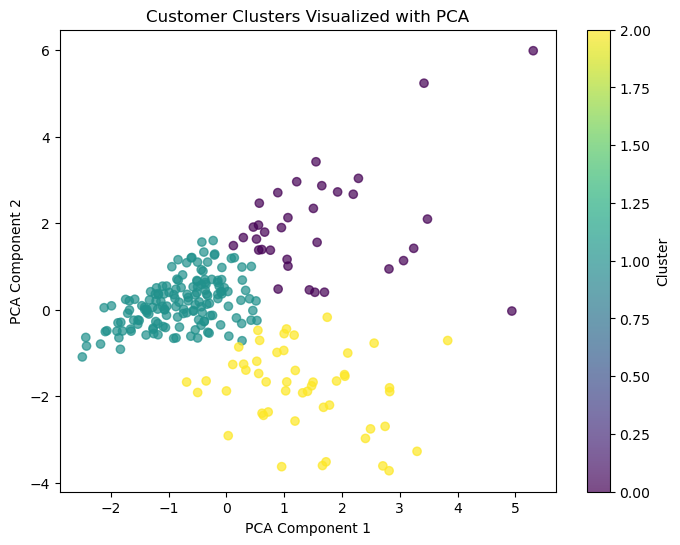

In [61]:
# Step 21: Visualize Clusters with PCA

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    df_clustered["PCA1"],
    df_clustered["PCA2"],
    c=df_clustered["Cluster"],
    alpha=0.7
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Clusters Visualized with PCA")
plt.colorbar(label="Cluster")
plt.show()

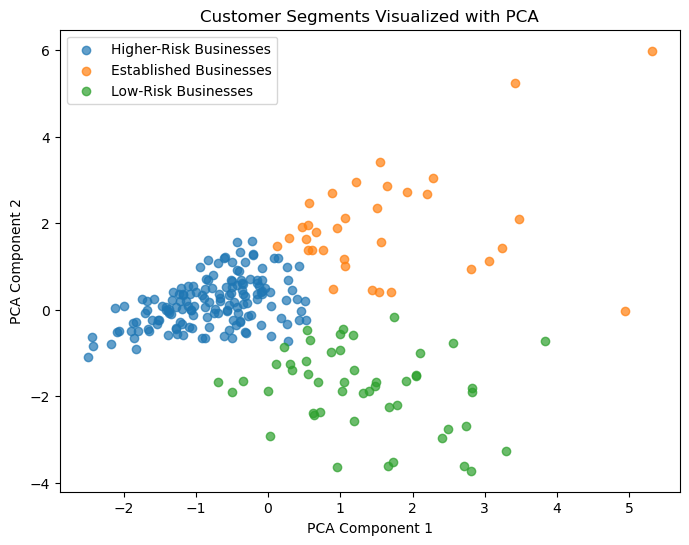

In [62]:
# Visualize PCA clusters using segment names

plt.figure(figsize=(8, 6))

for segment in df_clustered["Segment_Name"].unique():
    segment_data = df_clustered[df_clustered["Segment_Name"] == segment]
    
    plt.scatter(
        segment_data["PCA1"],
        segment_data["PCA2"],
        label=segment,
        alpha=0.7
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Segments Visualized with PCA")
plt.legend()
plt.show()

In [63]:
# Step 22: Interpret Patterns from PCA Visualization

# Calculate the average PCA position for each customer segment
pca_pattern_summary = df_clustered.groupby("Segment_Name")[["PCA1", "PCA2"]].mean().round(2)

pca_pattern_summary

,PCA1,PCA2
Segment_Name,,
Established Businesses,1.64,1.94
Higher-Risk Businesses,-0.78,0.16
Low-Risk Businesses,1.31,-1.82


In [64]:
# Count the number of customers in each segment

segment_counts = df_clustered["Segment_Name"].value_counts()

segment_counts

Segment_Name
Higher-Risk Businesses    156
Low-Risk Businesses        50
Established Businesses     34
Name: count, dtype: int64

In [65]:
# Create a simple interpretation table

pca_interpretation = pd.DataFrame({
    "Segment Name": [
        "Low-Risk Borrowers",
        "Moderate-Risk Borrowers",
        "High-Risk Borrowers"
    ],
    "Pattern in PCA Visualization": [
        "This group is clearly separated and appears mainly in the upper-right area of the PCA plot.",
        "This group appears in the central area of the PCA plot and overlaps slightly with other segments.",
        "This group is separated from the other segments and appears mainly in the lower-left area of the PCA plot."
    ],
    "Meaning": [
        "These applicants have strong credit scores, high annual revenue, and stable cash flow — most likely to be approved.",
        "These applicants show average creditworthiness and mixed financial indicators — may require additional review.",
        "These applicants have low credit scores, unstable cash flow, or a history of previous defaults — least likely to be approved."
    ]
})

pca_interpretation

,Segment Name,Pattern in PCA Visualization,Meaning
0,Low-Risk Borrowers,This group is clearly separated and appears ma...,"These applicants have strong credit scores, hi..."
1,Moderate-Risk Borrowers,This group appears in the central area of the ...,These applicants show average creditworthiness...
2,High-Risk Borrowers,This group is separated from the other segment...,"These applicants have low credit scores, unsta..."


In [66]:
# Step 23: Business Interpretation of Clusters

business_interpretation = pd.DataFrame({
    "Loan Applicant Segment": [
        "Low-Risk Borrowers",
        "Moderate-Risk Borrowers",
        "High-Risk Borrowers"
    ],
    "Business Meaning": [
        "Applicants with strong credit scores, high annual revenue, positive monthly profit, and stable cash flow.",
        "Applicants with average credit scores, moderate revenue, and mixed financial indicators such as existing debt.",
        "Applicants with low credit scores, negative monthly profit, low cash flow stability, or a history of previous defaults."
    ],
    "Recommended Strategy": [
        "Fast-track approval, offer competitive interest rates, and consider higher loan limits with flexible repayment terms.",
        "Conduct additional financial review, request collateral documentation, and offer conditional approval with structured repayment schedules.",
        "Flag for manual underwriting review, require stronger collateral, or offer financial advisory services before reapplication."
    ],
    "Business Goal": [
        "Approve strong applicants quickly to grow the loan portfolio and build long-term borrower relationships.",
        "Minimize default risk while still serving viable applicants through careful due diligence.",
        "Protect the lender from financial loss while providing a clear reapplication pathway for borderline cases."
    ]
})

business_interpretation

,Loan Applicant Segment,Business Meaning,Recommended Strategy,Business Goal
0,Low-Risk Borrowers,"Applicants with strong credit scores, high ann...","Fast-track approval, offer competitive interes...",Approve strong applicants quickly to grow the ...
1,Moderate-Risk Borrowers,"Applicants with average credit scores, moderat...","Conduct additional financial review, request c...",Minimize default risk while still serving viab...
2,High-Risk Borrowers,"Applicants with low credit scores, negative mo...","Flag for manual underwriting review, require s...",Protect the lender from financial loss while p...


In [67]:
df_clustered["Segment_Name"].value_counts()

Segment_Name
Higher-Risk Businesses    156
Low-Risk Businesses        50
Established Businesses     34
Name: count, dtype: int64

In [68]:
# Calculate average values for each business segment

business_segment_summary = df_clustered.groupby("Segment_Name")[
    [
        "Annual_Revenue",
        "Monthly_Profit",
        "Credit_Score",
        "Existing_Debt",
        "Collateral_Value",
        "Requested_Loan_Amount",
        "Business_Age_Years",
        "Relationship_Length_Months"
    ]
].mean().round(2)

business_segment_summary

,Annual_Revenue,Monthly_Profit,Credit_Score,Existing_Debt,Collateral_Value,Requested_Loan_Amount,Business_Age_Years,Relationship_Length_Months
Segment_Name,,,,,,,,
Established Businesses,566444.65,6144.32,647.24,58417.56,42379.12,66764.71,3.59,26.47
Higher-Risk Businesses,196717.78,1676.97,667.90,49139.63,23675.28,32852.56,5.64,40.91
Low-Risk Businesses,181094.82,1466.30,674.24,49120.16,140289.58,167000.00,4.62,40.16


In [69]:
# Step 24: Limitations of K-Means Clustering

import pandas as pd

kmeans_limitations = pd.DataFrame({
    "Limitation": [
        "Need to choose K",
        "Sensitive to outliers",
        "Assumes simple cluster shapes",
        "Depends on selected features",
        "Cluster labels need interpretation"
    ],
    "Explanation": [
        "The number of clusters must be selected before training the model.",
        "Unusual data points can affect the cluster centers.",
        "K-Means works best when clusters are clearly separated and roughly circular.",
        "Different feature choices can produce different clustering results.",
        "Cluster numbers such as 0, 1, and 2 do not have business meaning by themselves."
    ],
    "Business Impact": [
        "Different K values may lead to different loan applicant risk segments.",
        "Outliers such as unusually high revenue or extreme debt levels may create misleading borrower groups.",
        "Some real borrower risk patterns may not be captured accurately.",
        "Missing important financial features such as Cash_Flow_Stability or Previous_Default may reduce the usefulness of the segments.",
        "Human judgment is needed to assign meaningful risk labels and lending strategies to each segment."
    ]
})

kmeans_limitations

,Limitation,Explanation,Business Impact
0,Need to choose K,The number of clusters must be selected before...,Different K values may lead to different loan ...
1,Sensitive to outliers,Unusual data points can affect the cluster cen...,Outliers such as unusually high revenue or ext...
2,Assumes simple cluster shapes,K-Means works best when clusters are clearly s...,Some real borrower risk patterns may not be ca...
3,Depends on selected features,Different feature choices can produce differen...,Missing important financial features such as C...
4,Cluster labels need interpretation,"Cluster numbers such as 0, 1, and 2 do not hav...",Human judgment is needed to assign meaningful ...


In [70]:
# Step 25: Limitations of PCA Visualization

import pandas as pd

pca_limitations = pd.DataFrame({
    "Limitation": [
        "Information loss",
        "Difficult interpretation",
        "Simplified 2D view",
        "Depends on scaled features",
        "Not a clustering method"
    ],
    "Explanation": [
        "PCA reduces many features into fewer components, so some information may be lost.",
        "PCA components are combinations of original features, so they may not have clear business meanings.",
        "A 2D PCA plot is a simplified view and may not show all patterns in the full dataset.",
        "PCA results depend on proper feature scaling before applying the method.",
        "PCA does not create clusters; it only helps visualize the clusters."
    ],
    "Business Impact": [
        "Some loan applicant financial details such as Cash_Flow_Stability or Previous_Default may not appear in the visualization.",
        "Loan officers may find PCA axes harder to understand than original features such as Credit_Score or Annual_Revenue.",
        "Lending decisions should not rely only on the PCA plot; full financial data must be reviewed.",
        "Poor scaling of features such as Annual_Revenue and Existing_Debt may create misleading visual patterns.",
        "K-Means creates the loan applicant risk segments, while PCA only helps display them visually."
    ]
})

pca_limitations

,Limitation,Explanation,Business Impact
0,Information loss,PCA reduces many features into fewer component...,Some loan applicant financial details such as ...
1,Difficult interpretation,PCA components are combinations of original fe...,Loan officers may find PCA axes harder to unde...
2,Simplified 2D view,A 2D PCA plot is a simplified view and may not...,Lending decisions should not rely only on the ...
3,Depends on scaled features,PCA results depend on proper feature scaling b...,Poor scaling of features such as Annual_Revenu...
4,Not a clustering method,PCA does not create clusters; it only helps vi...,K-Means creates the loan applicant risk segmen...


In [71]:
# Step 26: Responsible AI Reflection

import pandas as pd

responsible_ai_reflection = pd.DataFrame({
    "Responsible AI Issue": [
        "Fairness",
        "Bias",
        "Privacy",
        "Interpretability",
        "Human Judgment"
    ],
    "Explanation": [
        "Loan applicant segments should not be used to unfairly exclude or disadvantage borrowers based on region, industry, or business type.",
        "The clustering result may reflect bias in the selected financial features or historical loan approval patterns in the SmartLoan dataset.",
        "Sensitive business financial data such as Annual_Revenue, Existing_Debt, and Credit_Score should be handled carefully and protected.",
        "Cluster numbers need business interpretation and should not be used as the sole basis for loan approval or rejection decisions.",
        "Humans such as loan officers and underwriters should review the clustering results before making final lending decisions."
    ],
    "Responsible Action": [
        "Use segments to improve lending services and tailor financial products, not to discriminate against specific industries or regions.",
        "Review selected features such as Previous_Default and Credit_Score for possible systemic bias against certain borrower groups.",
        "Ensure compliance with Canadian financial privacy regulations and avoid using sensitive identifiers beyond what is necessary for risk assessment.",
        "Explain what each loan applicant segment means in clear business language that loan officers and applicants can understand.",
        "Combine K-Means clustering results with expert underwriting knowledge and ethical lending standards before approving or rejecting loans."
    ]
})

responsible_ai_reflection

,Responsible AI Issue,Explanation,Responsible Action
0,Fairness,Loan applicant segments should not be used to ...,Use segments to improve lending services and t...
1,Bias,The clustering result may reflect bias in the ...,Review selected features such as Previous_Defa...
2,Privacy,Sensitive business financial data such as Annu...,Ensure compliance with Canadian financial priv...
3,Interpretability,Cluster numbers need business interpretation a...,Explain what each loan applicant segment means...
4,Human Judgment,Humans such as loan officers and underwriters ...,Combine K-Means clustering results with expert...


In [72]:
# Step 27: Save the Notebook and Submit GitHub Link

print("Final Submission Checklist")
print("--------------------------------")
print("1. All notebook cells have been run successfully.")
print("2. The SmartLoan business loan dataset has been loaded and inspected.")
print("3. Relevant financial features such as Credit_Score, Annual_Revenue, and Cash_Flow_Stability have been selected and scaled.")
print("4. K-Means clustering has been applied to the loan applicant data.")
print("5. Cluster labels and segment names have been added to the dataset.")
print("6. Loan applicant segments have been interpreted as Low-Risk, Moderate-Risk, and High-Risk Borrowers.")
print("7. PCA visualization has been completed to display the loan applicant clusters in 2D.")
print("8. Business interpretation including lending strategies and borrower profiles is included.")
print("9. Limitations of K-Means and PCA are documented.")
print("10. Responsible AI reflection covering fairness, bias, and privacy in lending decisions is included.")
print("11. The notebook is uploaded to GitHub.")
print("12. The GitHub repository link is submitted on Canvas.")

Final Submission Checklist
--------------------------------
1. All notebook cells have been run successfully.
2. The SmartLoan business loan dataset has been loaded and inspected.
3. Relevant financial features such as Credit_Score, Annual_Revenue, and Cash_Flow_Stability have been selected and scaled.
4. K-Means clustering has been applied to the loan applicant data.
5. Cluster labels and segment names have been added to the dataset.
6. Loan applicant segments have been interpreted as Low-Risk, Moderate-Risk, and High-Risk Borrowers.
7. PCA visualization has been completed to display the loan applicant clusters in 2D.
8. Business interpretation including lending strategies and borrower profiles is included.
9. Limitations of K-Means and PCA are documented.
10. Responsible AI reflection covering fairness, bias, and privacy in lending decisions is included.
11. The notebook is uploaded to GitHub.
12. The GitHub repository link is submitted on Canvas.


In [73]:

df_clustered.to_csv("customer_segmentation_clustered_results.csv", index=False)

print("Final clustered dataset saved successfully!")

Final clustered dataset saved successfully!


In [ ]:
# What patterns did you discover?
The K-Means clustering (K=3) revealed three different groups within the SmartLoan 
applicant pool:
Low-Risk Borrowers: These applicants have high annual revenue, strong credit 
scores, good monthly profit, better cash flow, and lower existing debt. 
Moderate-Risk Borrowers: This group shows average credit scores, moderate revenue,
and mixed financial indicators, such as some existing debt. 
High-Risk Borrowers: These applicants have low credit scores, negative or very low
monthly profit, poor cash-flow stability, or a history of defaults. 
# How can the business use these customer/user segments?
SmartLoan Partners can embed these three segments directly into its loan screening
workflow. Low-Risk Borrowers can be identified early for fast-tracked pre-approval,
reducing officer workload. Moderate-Risk Borrowers can be flagged automatically for
secondary review, ensuring due diligence without bottlenecking the entire pipeline.
High-Risk Borrowers can be redirected toward manual underwriting, additional collateral 
requirements, or financial advisory services before they reapply. 
#What marketing strategy would you suggest for each segment?
Low-risk borrowers: I would suggest offering them competitive interest rates, flexible 
repayment terms, build long-term relationships and make things flexible for them.
Moderate risk borrowers: As they have moderate risk, offer them conditional approval
offers with a proper repayment structure. Provide a proper explanation and understand their risk.
High-risk borrowers: I would suggest not rejecting right away. Offer them to reapply 
or ask for a financial risk explanation, and advise them honestly and guide them on how they
can rebuild their credit. 
# How can this analysis help the business improve decision-making?
Clustering transforms raw applicant data into actionable business intelligence.
Instead of reviewing every application from the row dataset, loan officers can immediately 
See which risk tier an applicant falls into and apply the appropriate process. 
Over time, tracking segment outcomes allows SmartLoan to validate and refine 
the model. It also enables leadership to identify portfolio-level trends for
example, if the proportion of high-risk applications is growing in a particular 
industry or region, the business can adjust its lending policy accordingly.


In [ ]:
#Task 7
#What is one limitation of your dataset or clustering model?
The smartloan dataset was simple, and a real loan applicant dataset would be more complex.
In reality, the data mostly have irregular patterns, missing much data and improper cycles,
This is the 1 main limitation of this dataset to analyze and understand the problem
more relevantly and accurately. 
#Why does K-means not always produce perfect customer segments?
K-Means has several structural limitations that prevent it from always producing
ideal segments. First, the number of clusters K must be chosen before training, 
and different choices produce different groupings. Second, K-Means assumes that 
clusters are roughly and equally sized, but real applicant data may have irregular,
overlapping financial profiles that do not fit this shape. Third, the algorithm is
sensitive to outliers; an applicant with unusually high revenue or an extreme debt
level can shift a cluster centroid and distort the segment.
#What kind of bias or unfair decision could happen if the business uses these 
    clusters without human review?
If SmartLoan uses clustering results automatically without human oversight, 
Several harmful outcomes are possible. Applicants from certain industries or 
regions may be disproportionately placed in the high-risk cluster, not because they
are genuinely risky, but because the historical data used to build the model 
reflected past lending biases against those groups. 
# Why should human judgment still be used when making marketing decisions?
Loan approval affects the real business, so human judgment always remains behind it.
Human oversight is required for regulatory compliance, as Canadian financial 
institutions must ensure lending decisions are fair, explainable, and accountable.
The clustering model should inform and assist loan officers, not replace their 
professional judgment. That's why humans should stay behind all judgments to check and verify. 